<a href="https://colab.research.google.com/github/Suhrobjonibodullayev/Mini-projects/blob/main/heart_failure_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score

In [ ]:
import kagglehub

path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


In [ ]:
for file in os.listdir(path):
    print(file)

df = pd.read_csv(os.path.join(path, "heart.csv"))
df.head()

heart.csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.info() # umumiy malumotlar , ustunlar turi, ustunlarda qiymatlar to'liqligi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.dtypes.value_counts() # har bir malumot turi nechtaligi

,count
int64,6
object,5
float64,1


In [ ]:
df.select_dtypes(include="object").nunique() # object malumot turlari , nunique orqali har bir ustundagi unique, (int,float), (np.number) numericlar ko'rish

,0
Sex,2
ChestPainType,4
RestingECG,3
ExerciseAngina,2
ST_Slope,3


In [ ]:
df.select_dtypes(include=['object']).columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [ ]:
df.select_dtypes("object").head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up


In [ ]:
df.HeartDisease.value_counts(normalize=True) # target ustunni malumotlar taqsimoti % da

,proportion
HeartDisease,
1,0.553377
0,0.446623


In [ ]:
df.isnull().sum().sort_values(ascending=False).head(3) # nan qiymatlar ko'rish

,0
Age,0
Sex,0
ChestPainType,0


In [ ]:
df.duplicated().sum() # duplicatlarni ko'rish

df[df.duplicated(keep=False)].head(3) # duplicated qatorlar

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


In [ ]:
# df.drop_duplicates(inplace=True) # duplicatlarni tashlab yuborish

In [ ]:
df.describe() # numeric ustunlar statistikasi , mean min, max, std ...

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df.describe(include="object") # objectlar haqida malumotlar

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


In [ ]:
df.corrwith(df["HeartDisease"], numeric_only=True).abs().sort_values(ascending=False) # targetga nisbatan correlation

,0
HeartDisease,1.000000
Oldpeak,0.403951
MaxHR,0.400421
Age,0.282039
FastingBS,0.267291
Cholesterol,0.232741
RestingBP,0.107589


In [ ]:
fig = px.pie(
    df,
    names="HeartDisease",
    title="HeartDisease",
    hole=0.4,
    template="plotly_dark"
)

fig.show()

In [ ]:
fig = px.histogram(
    df,
    x="Cholesterol",
    text_auto=True,
    template="plotly_dark"
)

fig.show()

In [ ]:
fig = px.bar(
    df,
    x="Sex",
    y="HeartDisease",
    color="Sex",
    template='plotly_dark',
    color_discrete_sequence=['crimson', 'teal'],
    text_auto=True, # Ustun ustiga qiymatlarni avtomatik yozish (True, '.2f', va hokazo)
    pattern_shape="Sex", # Ustunlarga tekstura (naqsh) berish - ustun nomi beriladi
    pattern_shape_sequence=['/', 'x'], # Teksturalar ketma-ketligi
    pattern_shape_map={
        "M": "/",
        "F": "x"
    } # Kategoriyaga qarab tekstura berish
)
fig.show()

In [ ]:
px.scatter(
    df.HeartDisease,
    df.Oldpeak,
    template="plotly_dark",

)


In [ ]:
# df["Sex"] = df["Sex"].apply(lambda x: 1 if x == "M" else 0)

# df["Sex"] = df["Sex"].replace({
#     "M": 1,
#     "F": 0
# })

In [ ]:
# encoding object ustunlarni numeric qilish

label = LabelEncoder()

df['Sex'] = label.fit_transform(df['Sex'])

df["ExerciseAngina"] = label.fit_transform(df['ExerciseAngina'])

# df = pd.get_dummies(df, columns=["ChestPainType"], dtype=int)

categorical_cols = [
    "ChestPainType",
    "RestingECG",
    "ST_Slope"
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [ ]:
df.corrwith(df["HeartDisease"], numeric_only=True).abs().sort_values(ascending=False)

,0
HeartDisease,1.000000
ST_Slope_Up,0.622164
ST_Slope_Flat,0.554134
ExerciseAngina,0.494282
Oldpeak,0.403951
ChestPainType_ATA,0.401924
MaxHR,0.400421
Sex,0.305445
Age,0.282039
FastingBS,0.267291


In [ ]:
df.describe()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.789760,132.396514,198.799564,0.233115,136.809368,0.404139,0.887364,0.553377,0.188453,0.221133,0.050109,0.601307,0.193900,0.501089,0.430283
std,9.432617,0.407701,18.514154,109.384145,0.423046,25.460334,0.490992,1.066570,0.497414,0.391287,0.415236,0.218289,0.489896,0.395567,0.500271,0.495386
min,28.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,130.000000,223.000000,0.000000,138.000000,0.000000,0.600000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,60.000000,1.000000,140.000000,267.000000,0.000000,156.000000,1.000000,1.500000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,77.000000,1.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Correlationni heatmap orqali ko'ramiz
corr = df.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="Greens",
    zmin=-1,
    zmax=1,
    title="Correlation Heatmap",
    labels=dict(x="Feature", y="Feature", color="Correlation"),
    template="plotly_dark"

)

fig.show()

In [ ]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# train/test

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

# LogisticRegression
LR = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

LR.fit(X_train,y_train)

pred = LR.predict(X_test)

In [ ]:
def evaluate(y_test,pred):
  print("accurecy:",accuracy_score(y_test,pred))
  print("precision:",precision_score(y_test,pred))
  print("recall:",recall_score(y_test,pred))
  print("f1:",f1_score(y_test,pred))
  print(confusion_matrix(y_test,pred))
  print(classification_report(y_test,pred))
  cm = confusion_matrix(y_test,pred)

  fig = px.imshow(
    cm,
    text_auto=True,
    x=["Normal", "Theft"],
    y=["Normal", "Theft"],
    title="Confusion Matrix",
    labels=dict(x="Predicted", y="Actual"),
    template="plotly_dark"
    )
  fig.update_xaxes(title="Predicted")
  fig.update_yaxes(title="Actual")

  fig.show()


evaluate(y_test,pred)


accurecy: 0.8913043478260869
precision: 0.8796296296296297
recall: 0.9313725490196079
f1: 0.9047619047619048
[[69 13]
 [ 7 95]]
              precision    recall  f1-score   support

           0       0.91      0.84      0.87        82
           1       0.88      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



In [ ]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train,y_train)

pred = knn.predict(X_test)

In [ ]:
evaluate(y_test,pred)
knn.score(X_train,y_train)

accurecy: 0.8858695652173914
precision: 0.8857142857142857
recall: 0.9117647058823529
f1: 0.8985507246376812
[[70 12]
 [ 9 93]]
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



0.8910081743869209

In [ ]:
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

svm.fit(X_train,y_train)

pred = svm.predict(X_test)

In [ ]:
evaluate(y_test,pred)
svm.score(X_train,y_train)

accurecy: 0.9021739130434783
precision: 0.8818181818181818
recall: 0.9509803921568627
f1: 0.9150943396226415
[[69 13]
 [ 5 97]]
              precision    recall  f1-score   support

           0       0.93      0.84      0.88        82
           1       0.88      0.95      0.92       102

    accuracy                           0.90       184
   macro avg       0.91      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



0.9019073569482289

In [ ]:
DT = DecisionTreeClassifier(max_depth=4)

DT.fit(X_train,y_train)

pred = DT.predict(X_test)

In [ ]:
evaluate(y_test,pred)
DT.score(X_train,y_train)

accurecy: 0.8369565217391305
precision: 0.8272727272727273
recall: 0.8921568627450981
f1: 0.8584905660377359
[[63 19]
 [11 91]]
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



0.8760217983651226

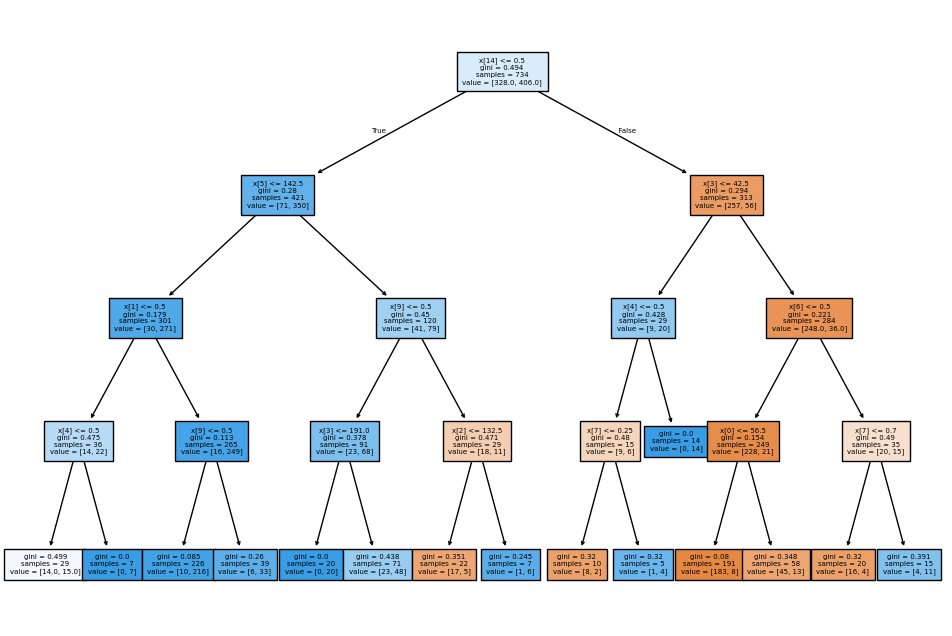

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(DT,filled=True, fontsize=5)
plt.show()

In [ ]:
RF = RandomForestClassifier(n_estimators=140, max_depth=9)

RF.fit(X_train,y_train)

pred = RF.predict(X_test)

In [ ]:
evaluate(y_test,pred)
RF.score(X_train,y_train)

accurecy: 0.8641304347826086
precision: 0.8737864077669902
recall: 0.8823529411764706
f1: 0.8780487804878049
[[69 13]
 [12 90]]
              precision    recall  f1-score   support

           0       0.85      0.84      0.85        82
           1       0.87      0.88      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



0.9727520435967303

## Best Model Support Vector Machine Testda 90 % aniqlik